# 08 — Hyperparameter Tuning

## Objective

Optimize the two strongest forecasting model families identified during
model comparison and feature-group ablation:

- Random Forest
- XGBoost

The complete feature set is retained:

- historical energy features;
- calendar features;
- load type.

Hyperparameter configurations will be evaluated using the same
expanding-window walk-forward validation protocol used in previous
notebooks.

Primary selection metric:

**Mean Absolute Error (MAE)**

The December 2018 test period remains completely untouched.

In [1]:
#Imports
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import ParameterSampler

from xgboost import XGBRegressor

In [3]:
#Load gold table
con = duckdb.connect(
    "Steel_energy.duckdb"
)

df = con.sql("""
SELECT *
FROM gold_energy_features
ORDER BY timestamp
""").df()

df = df.sort_values(
    "timestamp"
).reset_index(drop=True)

df.head()

,timestamp,usage_kwh,hour,month,day_of_week,week_status,load_type,usage_15min_ago,usage_1h_ago,usage_lag_96,avg_usage_previous_hour
0,2018-01-01 00:00:00,3.42,0,1,Monday,Weekday,Light_Load,NaN,NaN,NaN,NaN
1,2018-01-01 00:15:00,3.17,0,1,Monday,Weekday,Light_Load,3.42,NaN,NaN,3.4200
2,2018-01-01 00:30:00,4.00,0,1,Monday,Weekday,Light_Load,3.17,NaN,NaN,3.2950
3,2018-01-01 00:45:00,3.24,0,1,Monday,Weekday,Light_Load,4.00,NaN,NaN,3.5300
4,2018-01-01 01:00:00,3.31,1,1,Monday,Weekday,Light_Load,3.24,3.42,NaN,3.4575


In [4]:
#protect the final test dataset
development_df = df[
    df["timestamp"] < "2018-12-01"
].copy()

test_df = df[
    df["timestamp"] >= "2018-12-01"
].copy()

In [5]:
development_df = df[
    df["timestamp"] < "2018-12-01"
].copy()

test_df = df[
    df["timestamp"] >= "2018-12-01"
].copy()

In [6]:
development_df["timestamp"].min(), development_df["timestamp"].max()

(Timestamp('2018-01-01 00:00:00'), Timestamp('2018-11-30 23:45:00'))

In [7]:
#Define feature set
numeric_features = [
    "usage_15min_ago",
    "usage_1h_ago",
    "usage_lag_96",
    "avg_usage_previous_hour",
    "hour",
    "month"
]

categorical_features = [
    "day_of_week",
    "week_status",
    "load_type"
]

feature_columns = (
    numeric_features
    +
    categorical_features
)

target = "usage_kwh"

In [8]:
#Drop NULLs
development_df[
    feature_columns
].isna().sum()

usage_15min_ago             1
usage_1h_ago                4
usage_lag_96               96
avg_usage_previous_hour     1
hour                        0
month                       0
day_of_week                 0
week_status                 0
load_type                   0
dtype: int64

In [10]:
model_df = development_df.dropna(
    subset=feature_columns + [target]
).copy()

model_df.shape

(31968, 11)

In [11]:
#Preprocessor definition
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [12]:
#Metrics
def evaluate_forecast(
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [13]:
#Same folds
folds = [
    ("2018-05-01", "2018-06-01"),
    ("2018-06-01", "2018-07-01"),
    ("2018-07-01", "2018-08-01"),
    ("2018-08-01", "2018-09-01"),
    ("2018-09-01", "2018-10-01"),
    ("2018-10-01", "2018-11-01"),
    ("2018-11-01", "2018-12-01"),
]

In [14]:
#Function that builds a model
def build_model(
    model_name,
    params
):

    if model_name == "Random Forest":

        estimator = RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            **params
        )

    elif model_name == "XGBoost":

        estimator = XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            **params
        )

    else:

        raise ValueError(
            "Unknown model name"
        )

    return Pipeline([
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "model",
            estimator
        )
    ])

In [15]:
#Function to evaluate one hyperparameter configuration
def evaluate_configuration(
    model_name,
    params
):

    fold_results = []

    for fold_number, (
        val_start,
        val_end
    ) in enumerate(
        folds,
        start=1
    ):

        train = model_df[
            model_df["timestamp"] < val_start
        ].copy()

        val = model_df[
            (
                model_df["timestamp"] >= val_start
            )
            &
            (
                model_df["timestamp"] < val_end
            )
        ].copy()


        X_train = train[
            feature_columns
        ]

        y_train = train[
            target
        ]


        X_val = val[
            feature_columns
        ]

        y_val = val[
            target
        ]


        model = build_model(
            model_name,
            params
        )

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_val
        )

        metrics = evaluate_forecast(
            y_val,
            predictions
        )

        fold_results.append(
            metrics
        )


    fold_df = pd.DataFrame(
        fold_results
    )

    return {
        "MAE_mean":
            fold_df["MAE"].mean(),

        "MAE_std":
            fold_df["MAE"].std(),

        "RMSE_mean":
            fold_df["RMSE"].mean(),

        "R2_mean":
            fold_df["R2"].mean(),

        "R2_std":
            fold_df["R2"].std()
    }

In [16]:
#Define random forest search space
rf_param_space = {

    "n_estimators": [
        100,
        200,
        400,
        600
    ],

    "max_depth": [
        None,
        10,
        20,
        30
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        1.0,
        0.7,
        "sqrt"
    ]
}

In [17]:
#Sample random forest configurations
rf_candidates = list(
    ParameterSampler(
        rf_param_space,
        n_iter=15,
        random_state=42
    )
)

rf_candidates[:3]

[{'n_estimators': 100,
  'min_samples_split': 5,
  'min_samples_leaf': 4,
  'max_features': 'sqrt',
  'max_depth': 30},
 {'n_estimators': 600,
  'min_samples_split': 2,
  'min_samples_leaf': 1,
  'max_features': 'sqrt',
  'max_depth': None},
 {'n_estimators': 100,
  'min_samples_split': 2,
  'min_samples_leaf': 1,
  'max_features': 'sqrt',
  'max_depth': 10}]

In [18]:
#We evaluate random forest candidates
rf_results = []

for i, params in enumerate(
    rf_candidates,
    start=1
):

    print(
        f"RF configuration "
        f"{i}/{len(rf_candidates)}"
    )

    metrics = evaluate_configuration(
        "Random Forest",
        params
    )

    rf_results.append({
        "model": "Random Forest",
        "configuration": i,
        "params": params,
        **metrics
    })

RF configuration 1/15
RF configuration 2/15
RF configuration 3/15
RF configuration 4/15
RF configuration 5/15
RF configuration 6/15
RF configuration 7/15
RF configuration 8/15
RF configuration 9/15
RF configuration 10/15
RF configuration 11/15
RF configuration 12/15
RF configuration 13/15
RF configuration 14/15
RF configuration 15/15


In [19]:
#We get the results
rf_results_df = pd.DataFrame(
    rf_results
)

rf_results_df = rf_results_df.sort_values(
    "MAE_mean"
)

rf_results_df.head(10)

,model,configuration,params,MAE_mean,MAE_std,RMSE_mean,R2_mean,R2_std
11,Random Forest,12,"{'n_estimators': 400, 'min_samples_split': 10,...",4.925695,0.726135,10.140372,0.897263,0.012377
4,Random Forest,5,"{'n_estimators': 100, 'min_samples_split': 10,...",4.944773,0.723041,10.173107,0.896593,0.012158
5,Random Forest,6,"{'n_estimators': 600, 'min_samples_split': 10,...",4.947201,0.722065,10.131482,0.897419,0.012105
3,Random Forest,4,"{'n_estimators': 400, 'min_samples_split': 5, ...",4.948468,0.709267,10.265300,0.894733,0.012978
10,Random Forest,11,"{'n_estimators': 200, 'min_samples_split': 10,...",4.982963,0.720333,10.210386,0.895855,0.011642
7,Random Forest,8,"{'n_estimators': 400, 'min_samples_split': 10,...",4.984065,0.718709,10.212919,0.895792,0.011822
9,Random Forest,10,"{'n_estimators': 100, 'min_samples_split': 5, ...",4.990529,0.720782,10.254195,0.894966,0.012182
14,Random Forest,15,"{'n_estimators': 600, 'min_samples_split': 2, ...",5.005594,0.744439,10.200592,0.896082,0.011508
13,Random Forest,14,"{'n_estimators': 400, 'min_samples_split': 10,...",5.014117,0.691728,10.297295,0.894037,0.012681
6,Random Forest,7,"{'n_estimators': 400, 'min_samples_split': 5, ...",5.158700,0.779572,10.297778,0.894127,0.010977


In [20]:
#We check the best configuration
best_rf = rf_results_df.iloc[0]

best_rf

model                                                Random Forest
configuration                                                   12
params           {'n_estimators': 400, 'min_samples_split': 10,...
MAE_mean                                                  4.925695
MAE_std                                                   0.726135
RMSE_mean                                                10.140372
R2_mean                                                   0.897263
R2_std                                                    0.012377
Name: 11, dtype: object

In [21]:
#Now we move to XGBoost
#We define XGBoost search space
xgb_param_space = {

    "n_estimators": [
        100,
        200,
        400,
        600
    ],

    "max_depth": [
        3,
        5,
        7,
        9
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "subsample": [
        0.7,
        0.85,
        1.0
    ],

    "colsample_bytree": [
        0.7,
        0.85,
        1.0
    ],

    "reg_alpha": [
        0,
        0.1,
        1.0
    ],

    "reg_lambda": [
        1,
        5,
        10
    ]
}

In [22]:
#We define sample XGBoost configurations
xgb_candidates = list(
    ParameterSampler(
        xgb_param_space,
        n_iter=15,
        random_state=42
    )
)

xgb_candidates[:3]

[{'subsample': 1.0,
  'reg_lambda': 5,
  'reg_alpha': 1.0,
  'n_estimators': 600,
  'max_depth': 9,
  'learning_rate': 0.03,
  'colsample_bytree': 0.7},
 {'subsample': 0.85,
  'reg_lambda': 1,
  'reg_alpha': 1.0,
  'n_estimators': 600,
  'max_depth': 7,
  'learning_rate': 0.01,
  'colsample_bytree': 1.0},
 {'subsample': 1.0,
  'reg_lambda': 5,
  'reg_alpha': 0.1,
  'n_estimators': 400,
  'max_depth': 3,
  'learning_rate': 0.1,
  'colsample_bytree': 0.85}]

In [23]:
#We evaluate the candidates
xgb_results = []

for i, params in enumerate(
    xgb_candidates,
    start=1
):

    print(
        f"XGB configuration "
        f"{i}/{len(xgb_candidates)}"
    )

    metrics = evaluate_configuration(
        "XGBoost",
        params
    )

    xgb_results.append({
        "model": "XGBoost",
        "configuration": i,
        "params": params,
        **metrics
    })

XGB configuration 1/15
XGB configuration 2/15
XGB configuration 3/15
XGB configuration 4/15
XGB configuration 5/15
XGB configuration 6/15
XGB configuration 7/15
XGB configuration 8/15
XGB configuration 9/15
XGB configuration 10/15
XGB configuration 11/15
XGB configuration 12/15
XGB configuration 13/15
XGB configuration 14/15
XGB configuration 15/15


In [24]:
#Check XGBoost results
xgb_results_df = pd.DataFrame(
    xgb_results
)

xgb_results_df = (
    xgb_results_df
    .sort_values(
        "MAE_mean"
    )
)

xgb_results_df.head(10)

,model,configuration,params,MAE_mean,MAE_std,RMSE_mean,R2_mean,R2_std
1,XGBoost,2,"{'subsample': 0.85, 'reg_lambda': 1, 'reg_alph...",4.839999,0.648905,9.953629,0.901088,0.010536
12,XGBoost,13,"{'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha...",4.915146,0.693244,10.028759,0.899531,0.010887
7,XGBoost,8,"{'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha...",4.994684,0.697309,10.112427,0.897946,0.009534
14,XGBoost,15,"{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha...",5.008904,0.713146,10.148655,0.897046,0.011528
0,XGBoost,1,"{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha...",5.010398,0.733818,10.177474,0.896573,0.009886
6,XGBoost,7,"{'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha...",5.074997,0.739595,10.173408,0.896607,0.012468
13,XGBoost,14,"{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha...",5.158246,0.703611,10.568362,0.888388,0.011377
9,XGBoost,10,"{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha...",5.227092,0.759715,10.512883,0.889664,0.010094
5,XGBoost,6,"{'subsample': 0.7, 'reg_lambda': 10, 'reg_alph...",5.255622,0.774493,10.602770,0.887743,0.008549
2,XGBoost,3,"{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha...",5.360883,0.685386,10.344466,0.893099,0.011220


In [25]:
#check best XGB configuration
best_xgb = xgb_results_df.iloc[0]

best_xgb

model                                                      XGBoost
configuration                                                    2
params           {'subsample': 0.85, 'reg_lambda': 1, 'reg_alph...
MAE_mean                                                  4.839999
MAE_std                                                   0.648905
RMSE_mean                                                 9.953629
R2_mean                                                   0.901088
R2_std                                                    0.010536
Name: 1, dtype: object

In [27]:
best_xgb_params = best_xgb["params"]

best_xgb_params

{'subsample': 0.85,
 'reg_lambda': 1,
 'reg_alpha': 1.0,
 'n_estimators': 600,
 'max_depth': 7,
 'learning_rate': 0.01,
 'colsample_bytree': 1.0}

In [37]:
#we compare with defaults

#RF default
default_rf_params = {
    "n_estimators": 100
}

default_rf_metrics = (
    evaluate_configuration(
        "Random Forest",
        default_rf_params
    )
)

default_rf_metrics

{'MAE_mean': np.float64(5.088595747604416),
 'MAE_std': np.float64(0.7195454796546816),
 'RMSE_mean': np.float64(10.450835369182544),
 'R2_mean': np.float64(0.8909168255174746),
 'R2_std': np.float64(0.01275283682706727)}

In [29]:
#XGB default
default_xgb_params = {}

In [30]:
default_xgb_metrics = (
    evaluate_configuration(
        "XGBoost",
        default_xgb_params
    )
)

default_xgb_metrics

{'MAE_mean': np.float64(5.059619332001633),
 'MAE_std': np.float64(0.6415190452865918),
 'RMSE_mean': np.float64(10.42937257280728),
 'R2_mean': np.float64(0.8912100431647672),
 'R2_std': np.float64(0.011222609782718367)}

In [31]:
#We build the final tuning comparison
comparison = pd.DataFrame([
    {
        "model":
            "Random Forest Default",

        **default_rf_metrics
    },

    {
        "model":
            "Random Forest Tuned",

        "MAE_mean":
            best_rf["MAE_mean"],

        "MAE_std":
            best_rf["MAE_std"],

        "RMSE_mean":
            best_rf["RMSE_mean"],

        "R2_mean":
            best_rf["R2_mean"],

        "R2_std":
            best_rf["R2_std"]
    },

    {
        "model":
            "XGBoost Default",

        **default_xgb_metrics
    },

    {
        "model":
            "XGBoost Tuned",

        "MAE_mean":
            best_xgb["MAE_mean"],

        "MAE_std":
            best_xgb["MAE_std"],

        "RMSE_mean":
            best_xgb["RMSE_mean"],

        "R2_mean":
            best_xgb["R2_mean"],

        "R2_std":
            best_xgb["R2_std"]
    }
])

In [32]:
comparison = comparison.sort_values(
    "MAE_mean"
)

comparison

,model,MAE_mean,MAE_std,RMSE_mean,R2_mean,R2_std
3,XGBoost Tuned,4.839999,0.648905,9.953629,0.901088,0.010536
1,Random Forest Tuned,4.925695,0.726135,10.140372,0.897263,0.012377
2,XGBoost Default,5.059619,0.641519,10.429373,0.891210,0.011223
0,Random Forest Default,5.088596,0.719545,10.450835,0.890917,0.012753


In [33]:
#We calculate the tuning improvement
rf_tuning_improvement = (
    (
        default_rf_metrics["MAE_mean"]
        -
        best_rf["MAE_mean"]
    )
    /
    default_rf_metrics["MAE_mean"]
    *
    100
)

rf_tuning_improvement

np.float64(3.20129879041317)

In [34]:
xgb_tuning_improvement = (
    (
        default_xgb_metrics["MAE_mean"]
        -
        best_xgb["MAE_mean"]
    )
    /
    default_xgb_metrics["MAE_mean"]
    *
    100
)

xgb_tuning_improvement

np.float64(4.340650824752788)

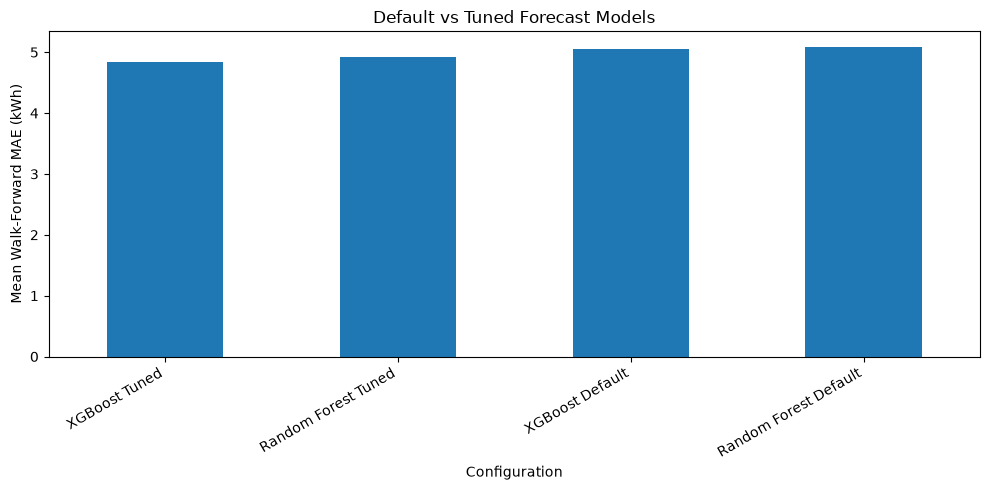

In [35]:
#And run a comparison
comparison.set_index(
    "model"
)["MAE_mean"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel(
    "Mean Walk-Forward MAE (kWh)"
)

plt.xlabel(
    "Configuration"
)

plt.title(
    "Default vs Tuned Forecast Models"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()

In [36]:
#We then select the final configuration
best_overall = comparison.iloc[0]

best_overall

model        XGBoost Tuned
MAE_mean          4.839999
MAE_std           0.648905
RMSE_mean         9.953629
R2_mean           0.901088
R2_std            0.010536
Name: 3, dtype: object

# Hyperparameter Tuning Conclusions

Random Forest and XGBoost were tuned using randomized hyperparameter
search while preserving the same expanding-window walk-forward
validation protocol used throughout model development.

The default XGBoost configuration achieved:

- Mean MAE: 5.06 kWh
- Mean RMSE: 10.43 kWh
- Mean R²: 0.891

The best tuned XGBoost configuration achieved:

- Mean MAE: 4.84 kWh
- MAE standard deviation: 0.65 kWh
- Mean RMSE: 9.95 kWh
- Mean R²: 0.901

Hyperparameter tuning reduced XGBoost MAE by approximately 4.34%
relative to its default configuration.

The tuned Random Forest also improved, reaching a mean MAE of
approximately 4.93 kWh, corresponding to a 3.20% improvement over
its default configuration.

The tuned XGBoost therefore produced the strongest development-set
performance and was selected as the final candidate model.

Relative to the original 15-minute persistence benchmark, the tuned
XGBoost reduced mean walk-forward MAE by approximately 19%.

The improvement from tuning was meaningful but smaller than the gains
obtained earlier from model-family selection and feature-group design,
showing that problem formulation and feature information contributed
more value than hyperparameter optimization alone.

The December 2018 test period remains untouched.